In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
# external imports
from pathlib import Path
import os
from dotenv import load_dotenv
from torch_geometric.data import Batch
import torch

In [3]:
# internal imports
from primaite.network.generator import NetworkGenerator
from primaite.agents.aegis.modules.openai import OpenAIClient


2024-09-10 08:29:01.795448: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2024-09-10 08:29:01.842383: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-09-10 08:29:02.502652: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
/home/jonathan/projects/primaite/PrimAITE/aegis/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/jonathan/projects/primaite/PrimAITE/aegis/lib/python3.10/site-packages/pydantic/_internal/_fields.py:161: UserWarning: Field "model_id" has 

In [4]:
# constants
NUMBER_OF_NODES = 30
RANDOM_SEED = 165116
TRAINING_CONFIG_PATH = Path("../agents") / "training_configs" / "do_nothing.yaml"
SERVICE_NAMES = ["HTTP", "SSH", "FTP"]
PORTS_LIST = ["80", "22", "21"]
DATASET_SAVE_PATH = Path("../data") / "generated_data" / "data.pt"

In [5]:
load_dotenv() 
open_ai_key = os.getenv('OPEN_AI_KEY')

openai = OpenAIClient(api_key=open_ai_key)

2024-09-10 08:30:16,210: Using: AgentFramework.CUSTOM, AgentIdentifier.DO_NOTHING, ActionType.NODE, observation_space=NODE_LINK_TABLE, 1 episodes @ 128 steps
2024-09-10 08:30:16,276: Environment configuration loaded
2024-09-10 08:30:16,403: Initialising <primaite.environment.observations.NodeLinkTable object at 0x7fde245a96f0> observation component
2024-09-10 08:30:16,408: Welcome to the Primary-level AI Training Environment (PrimAITE) (version: 2.0.1)
2024-09-10 08:30:16,409: The output directory for this session is: /home/jonathan/primaite/2.0.1/sessions/2024-09-10/2024-09-10_08-30-16


{'end_step': 121, 'id': '0', 'initiator': 'IER', 'item_type': 'RED_POL', 'nodeId': '18', 'protocol': 'SSH', 'sourceNodeId': '0', 'sourceNodeService': 'SSH', 'sourceNodeServiceState': 'ON', 'start_step': 117, 'state': 'ON', 'targetNodeId': '18', 'type': 'OPERATING'}
{'end_step': 78, 'id': '1', 'initiator': 'IER', 'item_type': 'RED_POL', 'nodeId': '29', 'protocol': 'SSH', 'sourceNodeId': '5', 'sourceNodeService': 'SSH', 'sourceNodeServiceState': 'BOOTING', 'start_step': 60, 'state': 'BOOTING', 'targetNodeId': '29', 'type': 'OPERATING'}
{'end_step': 105, 'id': '2', 'initiator': 'IER', 'item_type': 'RED_POL', 'nodeId': '19', 'protocol': 'SSH', 'sourceNodeId': '7', 'sourceNodeService': 'SSH', 'sourceNodeServiceState': 'OVERWHELMED', 'start_step': 48, 'state': 'OVERWHELMED', 'targetNodeId': '19', 'type': 'OS'}
{'end_step': 108, 'id': '3', 'initiator': 'IER', 'item_type': 'RED_POL', 'nodeId': '5', 'protocol': 'FTP', 'sourceNodeId': '1', 'sourceNodeService': 'FTP', 'sourceNodeServiceState': 'N

2024-09-10 08:30:18,380: Using: AgentFramework.CUSTOM, AgentIdentifier.DO_NOTHING, ActionType.NODE, observation_space=NODE_LINK_TABLE, 1 episodes @ 128 steps
2024-09-10 08:30:18,445: Environment configuration loaded
2024-09-10 08:30:18,571: Initialising <primaite.environment.observations.NodeLinkTable object at 0x7fde244cc670> observation component
2024-09-10 08:30:18,576: Welcome to the Primary-level AI Training Environment (PrimAITE) (version: 2.0.1)
2024-09-10 08:30:18,577: The output directory for this session is: /home/jonathan/primaite/2.0.1/sessions/2024-09-10/2024-09-10_08-30-18
2024-09-10 08:30:18,580: The Nodes hardware state is OFF so OS State cannot be changed. Node.node_id:3, Node.hardware_state:HardwareState.OFF, Node.software_state:SoftwareState.PATCHING
2024-09-10 08:30:18,580: The Nodes hardware state is OFF so OS State cannot be changed. Node.node_id:3, Node.hardware_state:HardwareState.OFF, Node.software_state:SoftwareState.PATCHING
2024-09-10 08:30:18,581: The Nodes

{'end_step': 121, 'id': '0', 'initiator': 'IER', 'item_type': 'RED_POL', 'nodeId': '18', 'protocol': 'SSH', 'sourceNodeId': '0', 'sourceNodeService': 'SSH', 'sourceNodeServiceState': 'ON', 'start_step': 117, 'state': 'ON', 'targetNodeId': '18', 'type': 'OPERATING'}
{'end_step': 78, 'id': '1', 'initiator': 'IER', 'item_type': 'RED_POL', 'nodeId': '29', 'protocol': 'SSH', 'sourceNodeId': '5', 'sourceNodeService': 'SSH', 'sourceNodeServiceState': 'BOOTING', 'start_step': 60, 'state': 'BOOTING', 'targetNodeId': '29', 'type': 'OPERATING'}
{'end_step': 105, 'id': '2', 'initiator': 'IER', 'item_type': 'RED_POL', 'nodeId': '19', 'protocol': 'SSH', 'sourceNodeId': '7', 'sourceNodeService': 'SSH', 'sourceNodeServiceState': 'OVERWHELMED', 'start_step': 48, 'state': 'OVERWHELMED', 'targetNodeId': '19', 'type': 'OS'}
{'end_step': 108, 'id': '3', 'initiator': 'IER', 'item_type': 'RED_POL', 'nodeId': '5', 'protocol': 'FTP', 'sourceNodeId': '1', 'sourceNodeService': 'FTP', 'sourceNodeServiceState': 'N

2024-09-10 08:30:18,647: The Nodes hardware state is OFF so OS State cannot be changed. Node.node_id:3, Node.hardware_state:HardwareState.OFF, Node.software_state:SoftwareState.PATCHING
2024-09-10 08:30:18,648: The Nodes hardware state is OFF so OS State cannot be changed. Node.node_id:3, Node.hardware_state:HardwareState.OFF, Node.software_state:SoftwareState.PATCHING
2024-09-10 08:30:18,648: The Nodes hardware state is OFF so File System State cannot be changed. Node.node_id:3, Node.hardware_state:HardwareState.OFF, Node.file_system_state.actual:FileSystemState.CORRUPT
2024-09-10 08:30:18,649: The Nodes hardware state is OFF so File System State cannot be changed. Node.node_id:3, Node.hardware_state:HardwareState.OFF, Node.file_system_state.actual:FileSystemState.CORRUPT
2024-09-10 08:30:18,649: The Nodes hardware state is OFF so the state of a service cannot be changed. Node.node_id:3, Node.hardware_state:HardwareState.OFF, Node.services[<key>]:FTP, Node.services[<key>].software_sta

<Figure size 640x480 with 0 Axes>

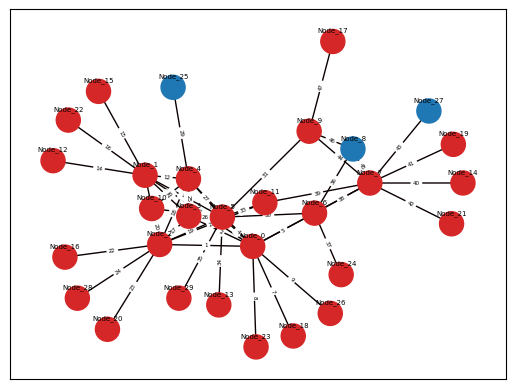

In [11]:
import random


outputs = []
for i in range(1):
    laydown_save_path = Path("../data") / "notebook_generated" / "laydowns" / f"{i}.yaml"
    graph_size = random.randint(10, 30)
    generator = NetworkGenerator(graph_size=graph_size, training_config_path=TRAINING_CONFIG_PATH, random_seed=1729, services=SERVICE_NAMES, ports=PORTS_LIST, pretrained_llm=openai)
    output = generator.run_end_to_end(laydown_save_path=laydown_save_path)
    outputs.append(output)

In [7]:
generator.network_description

'\nNodes:\n[\n  {\n    "Name":"Node_0",\n    "Type":"SERVER"\n  },\n  {\n    "Name":"Node_1",\n    "Type":"SERVER"\n  },\n  {\n    "Name":"Node_2",\n    "Type":"SERVER"\n  },\n  {\n    "Name":"Node_3",\n    "Type":"LINK"\n  },\n  {\n    "Name":"Node_4",\n    "Type":"SERVER"\n  },\n  {\n    "Name":"Node_5",\n    "Type":"SERVER"\n  },\n  {\n    "Name":"Node_6",\n    "Type":"CCTV"\n  },\n  {\n    "Name":"Node_7",\n    "Type":"SERVER"\n  },\n  {\n    "Name":"Node_8",\n    "Type":"CCTV"\n  },\n  {\n    "Name":"Node_9",\n    "Type":"CCTV"\n  },\n  {\n    "Name":"Node_10",\n    "Type":"COMPUTER"\n  },\n  {\n    "Name":"Node_11",\n    "Type":"CCTV"\n  },\n  {\n    "Name":"Node_12",\n    "Type":"SWITCH"\n  },\n  {\n    "Name":"Node_13",\n    "Type":"COMPUTER"\n  },\n  {\n    "Name":"Node_14",\n    "Type":"COMPUTER"\n  },\n  {\n    "Name":"Node_15",\n    "Type":"COMPUTER"\n  },\n  {\n    "Name":"Node_16",\n    "Type":"SWITCH"\n  },\n  {\n    "Name":"Node_17",\n    "Type":"LINK"\n  },\n  {\n    "

In [8]:
generator.nodes_dict

{'0': Node_0,
 '1': Node_1,
 '2': Node_2,
 '3': Node_3,
 '4': Node_4,
 '5': Node_5,
 '6': Node_6,
 '7': Node_7,
 '8': Node_8,
 '9': Node_9,
 '10': Node_10,
 '11': Node_11,
 '12': Node_12,
 '13': Node_13,
 '14': Node_14,
 '15': Node_15,
 '16': Node_16,
 '17': Node_17,
 '18': Node_18,
 '19': Node_19,
 '20': Node_20,
 '21': Node_21,
 '22': Node_22,
 '23': Node_23,
 '24': Node_24,
 '25': Node_25,
 '26': Node_26,
 '27': Node_27,
 '28': Node_28,
 '29': Node_29}

In [9]:
outputs[0]

Data(edge_index=[2, 96], id=[96], num_nodes=30, x=[30, 6], reasoning='Based on the network configuration, the node that is most vulnerable to attack and requires immediate action is Node_5. Node_5 is a SERVER node with multiple outgoing links and services. Taking defensive action on Node_5 by patching its software can help prevent further spread of potential attacks and ensure the stability of the network.', chosen_node='Node_5', node_property='SOFTWARE', property_action='PATCH', service_name='NONE', laydown_filename='0.yaml')

In [10]:
# batch = Batch.from_data_list(outputs)
# torch.save(batch, DATASET_SAVE_PATH)